
# Synthetic Business Analytics Project

This notebook performs exploratory data analysis (EDA) and builds predictive models using a synthetic business dataset. It demonstrates skills in data loading, visualization, feature engineering, and modeling suitable for roles like business analyst, program manager, or data analyst.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression

# Load the dataset
file_path = 'synthetic_business_data.csv'
df = pd.read_csv(file_path, parse_dates=['Date'])

df.head()


,Date,Product_Category,Region,Customer_Segment,Sales,Quantity,Discount,Marketing_Spend,Profit,High_Performance
0,2019-01-01 16:58:07,Electronics,North,Small Business,246.00,2,0.29,1246.94,100.16,0
1,2019-01-01 19:37:20,Electronics,West,Corporate,766.40,4,0.10,2741.08,283.12,0
2,2019-01-03 06:56:15,Electronics,East,Consumer,461.84,10,0.07,2859.49,846.28,1
3,2019-01-04 03:30:36,Furniture,South,Small Business,327.34,2,0.05,1157.12,153.36,0
4,2019-01-06 04:32:25,Furniture,North,Small Business,242.89,14,0.19,1411.13,201.42,0



## Summary statistics

Let's review summary statistics and data types to understand the distribution of numeric features and the composition of categorical variables.


In [2]:

# Display dataset info and summary statistics
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1000 non-null   datetime64[ns]
 1   Product_Category  1000 non-null   object        
 2   Region            1000 non-null   object        
 3   Customer_Segment  1000 non-null   object        
 4   Sales             1000 non-null   float64       
 5   Quantity          1000 non-null   int64         
 6   Discount          1000 non-null   float64       
 7   Marketing_Spend   1000 non-null   float64       
 8   Profit            1000 non-null   float64       
 9   High_Performance  1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 78.3+ KB


,Sales,Quantity,Discount,Marketing_Spend,Profit,High_Performance
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,219.786270,7.71800,0.147050,1895.623860,258.758620,0.250000
std,189.684719,4.00781,0.086306,570.920573,340.393691,0.433229
min,20.860000,1.00000,0.000000,500.000000,1.030000,0.000000
25%,67.200000,4.00000,0.070000,1500.467500,50.392500,0.000000
50%,131.400000,8.00000,0.145000,1913.840000,128.920000,0.000000
75%,349.877500,11.00000,0.220000,2297.690000,312.040000,0.250000
max,891.260000,14.00000,0.300000,3799.730000,2298.200000,1.000000



## Exploratory visualizations

Visualize relationships in the data:
- Distribution of sales by product category
- Boxplot of profit by region
- Correlation heatmap for numeric features
- Time-series plot of monthly total sales and profits


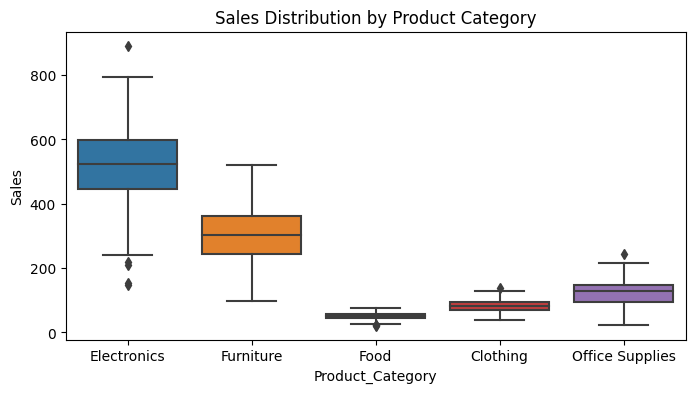

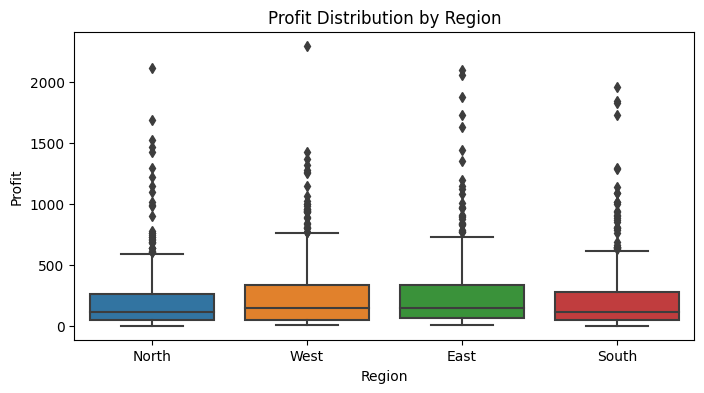

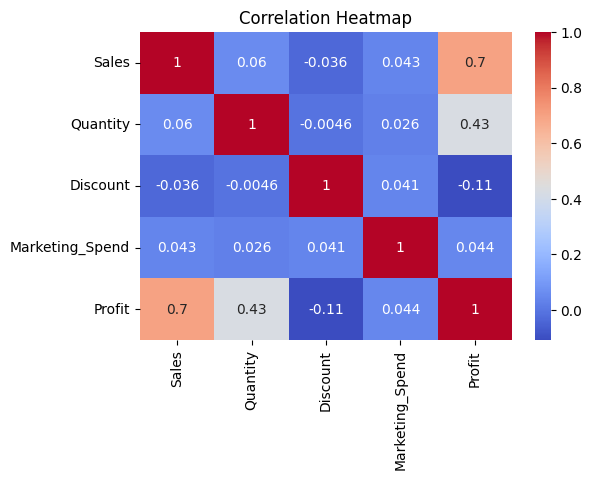

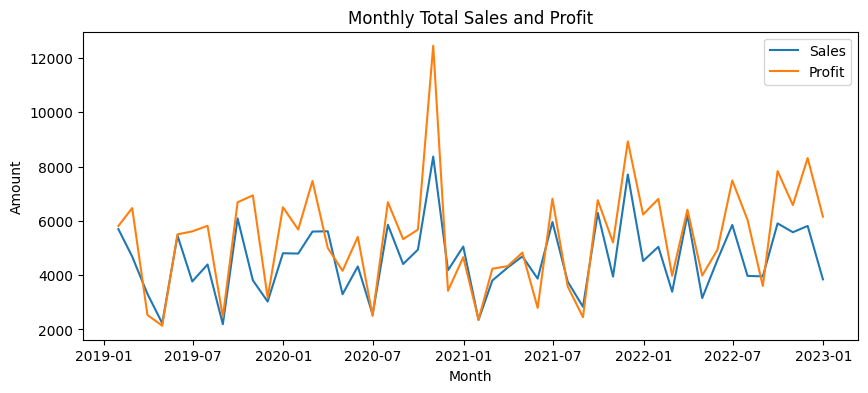

In [3]:

# Distribution of Sales by Product Category
plt.figure(figsize=(8,4))
sns.boxplot(x='Product_Category', y='Sales', data=df)
plt.title('Sales Distribution by Product Category')
plt.show()

# Profit by Region
plt.figure(figsize=(8,4))
sns.boxplot(x='Region', y='Profit', data=df)
plt.title('Profit Distribution by Region')
plt.show()

# Correlation heatmap
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Marketing_Spend', 'Profit']
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Time-series monthly sales and profit
monthly_df = df.resample('M', on='Date').agg({'Sales':'sum','Profit':'sum'})
plt.figure(figsize=(10,4))
plt.plot(monthly_df.index, monthly_df['Sales'], label='Sales')
plt.plot(monthly_df.index, monthly_df['Profit'], label='Profit')
plt.title('Monthly Total Sales and Profit')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.show()



## Predictive modeling

We'll build two models:

1. **Regression**: Predict `Profit` from other features using linear regression.
2. **Classification**: Predict whether a transaction is `High_Performance` (binary) using logistic regression.

We'll one-hot encode categorical variables and split the data into training and test sets.


In [4]:

# Prepare features and target for regression
X_reg = df.drop(columns=['Profit','High_Performance','Date'])
y_reg = df['Profit']

# Prepare features and target for classification
X_clf = df.drop(columns=['High_Performance','Profit','Date'])
y_clf = df['High_Performance']

categorical_cols = ['Product_Category','Region','Customer_Segment']
numeric_cols = ['Sales','Quantity','Discount','Marketing_Spend']

# Preprocess: one-hot encode categorical variables, pass-through numeric features
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])

# Regression pipeline
reg_model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', LinearRegression())])

# Classification pipeline
clf_model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', LogisticRegression(max_iter=1000))])

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Fit models
reg_model.fit(X_train_reg, y_train_reg)
clf_model.fit(X_train_clf, y_train_clf)

# Evaluate Regression
y_pred_reg = reg_model.predict(X_test_reg)
print('Regression model R^2:', r2_score(y_test_reg, y_pred_reg))
print('Regression model RMSE:', mean_squared_error(y_test_reg, y_pred_reg, squared=False))

# Evaluate Classification
y_pred_clf = clf_model.predict(X_test_clf)
print('Classification model accuracy:', accuracy_score(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))


Regression model R^2: 0.6510795807628956
Regression model RMSE: 205.0529064809083
Classification model accuracy: 0.925
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       155
           1       0.86      0.80      0.83        45

    accuracy                           0.93       200
   macro avg       0.90      0.88      0.89       200
weighted avg       0.92      0.93      0.92       200

